# Classification and Evaluation in NLP

**Text classification** is a common Natural Language Processing (NLP) task where a model assigns a predefined category or label to a piece of text.

Examples include:
- Spam detection
- Sentiment analysis(openion)
- News categorization

In this lab, we will learn how to build and evaluate a text classification model.

## Case Study: Sentiment Analysis

Sentiment analysis, also known as opinion mining, its goal is to understand the information present in the text and categorize it as positive, negative, or neutral.

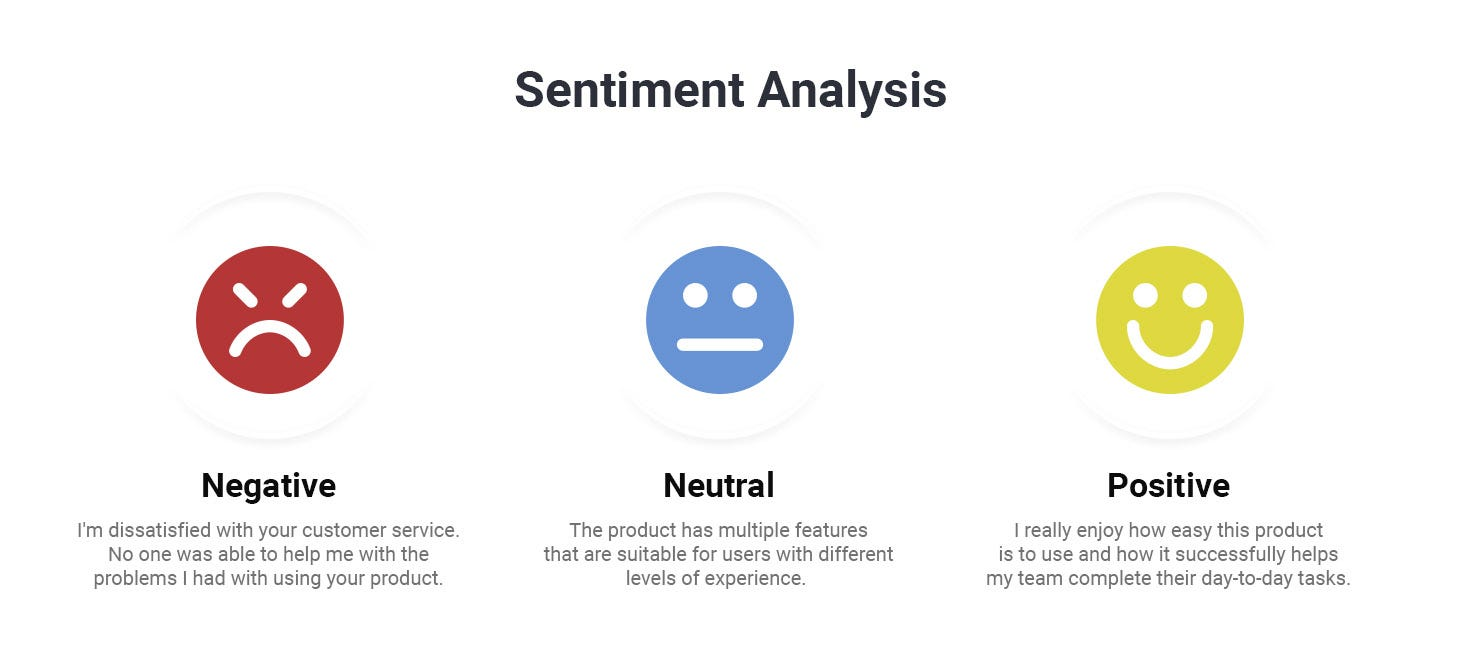

# Disneyland Reviews Dataset
In this lab we'll look into Disneyland Reviews dataset.  
*Link: https://www.kaggle.com/datasets/arushchillar/disneyland-reviews*

The dataset includes 42,000 reviews of 3 Disneyland branches - Paris, California and Hong Kong, posted by visitors on Trip Advisor.

Column Description:

- Review_ID: unique id given to each review
- Rating: ranging from 1 (unsatisfied) to 5 (satisfied)
- Year_Month: when the reviewer visited the theme park
- Reviewer_Location: country of origin of visitor
- Review_Text: comments made by visitor
- Disneyland_Branch: location of Disneyland Park

In [2]:
# Load the dataset
import pandas as pd

data = pd.read_csv('/content/DisneylandReviews.csv', encoding='latin-1')
data

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong
...,...,...,...,...,...,...
3750,395005989,4,2016-7,Australia,"Disneyland delivers on expectations, it's a sm...",Disneyland_HongKong
3751,394980687,3,2016-7,Malaysia,July 6 Group of 19 spent a day in Disneyland...,Disneyland_HongKong
3752,394962980,4,2015-8,Indonesia,Although smaller that the original Disney in U...,Disneyland_HongKong
3753,394918806,5,2015-12,Singapore,What can one say except this is Disneyland aft...,Disneyland_HongKong


In [3]:
#Check for missing values
data.isna().sum()

,0
Review_ID,0
Rating,0
Year_Month,0
Reviewer_Location,0
Review_Text,0
Branch,1


In [4]:
# Drop rows with missing values in the relevant columns
data = data.dropna(subset=['Review_Text', 'Rating'])

In [5]:
# Map star ratings to sentiments
data['Sentiment'] = data['Rating'].apply(lambda rating: 'positive' if rating > 3 else ('negative' if rating < 3 else 'neutral'))
data.head()

,Review_ID,Rating,Year_Month,Reviewer_Location,Review_Text,Branch,Sentiment
0,670772142,4,2019-4,Australia,If you've ever been to Disneyland anywhere you...,Disneyland_HongKong,positive
1,670682799,4,2019-5,Philippines,Its been a while since d last time we visit HK...,Disneyland_HongKong,positive
2,670623270,4,2019-4,United Arab Emirates,Thanks God it wasn t too hot or too humid wh...,Disneyland_HongKong,positive
3,670607911,4,2019-4,Australia,HK Disneyland is a great compact park. Unfortu...,Disneyland_HongKong,positive
4,670607296,4,2019-4,United Kingdom,"the location is not in the city, took around 1...",Disneyland_HongKong,positive


In [6]:
# Import necessary libraries
import re
import nltk

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenize the text
    words = text.split()

    return ' '.join(words)

# Apply preprocessing to the review text
data['Review_Text'] = data['Review_Text'].apply(preprocess_text)

# Display cleaned reviews
data[['Review_Text', 'Sentiment']].head()

,Review_Text,Sentiment
0,if youve ever been to disneyland anywhere youl...,positive
1,its been a while since d last time we visit hk...,positive
2,thanks god it wasn t too hot or too humid when...,positive
3,hk disneyland is a great compact park unfortun...,positive
4,the location is not in the city took around ho...,positive


In [12]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split the dataset into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data['Review_Text'], data['Sentiment'], test_size=0.2, random_state=42)


# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=1000)  # You can adjust max_features based on your dataset size - limit vocabulary to the 1000 most informative tokens
train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

In [13]:
print(f"train_data size: {train_data.shape}")
print(f"test_data size: {test_data.shape}")

train_data size: (3004,)
test_data size: (751,)


In [9]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train the Support Vector Machine (SVM) classifier
svm_classifier = SVC(kernel='linear')
svm_classifier.fit(train_vectors, train_labels)

# Predictions on the test set
predictions = svm_classifier.predict(test_vectors)

# Evaluate the model
accuracy = accuracy_score(test_labels, predictions)
print(f"Accuracy: {accuracy:.2f}")

# Display classification report
print("Classification Report:")
print(classification_report(test_labels, predictions))


Accuracy: 0.83
Classification Report:
              precision    recall  f1-score   support

    negative       0.50      0.03      0.06        29
     neutral       0.50      0.07      0.12       101
    positive       0.84      1.00      0.91       621

    accuracy                           0.83       751
   macro avg       0.61      0.37      0.37       751
weighted avg       0.78      0.83      0.77       751



# Use Case:  Amazon reviews of unlocked phone analysis

The objective of this use case is to conduct sentiment analysis on Amazon reviews of unlocked phones, categorizing reviews into three classes: positive, negative, and neutral. The goal is to gain a comprehensive understanding of customer opinions and sentiments regarding various unlocked phone models.

- Dataset link: https://www.kaggle.com/datasets/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

Task1: Load the data and do 5 different preprocessing steps on it

Task2: Use a proper train and test split

Task3: Do Feature Extraction Using TF-IDF

Task4: Train a Naive Bayes Classifier

Task5: Evaluate the model on the Test Set

Task6: Print the Confusion Matrix

Task1: Load the data and do 5 different preprocessing steps on it

In [15]:
import pandas as pd
import re

# Load the dataset
data = pd.read_csv('/content/Amazon_Unlocked_Mobile.csv')

# Keep only the required columns
data = data[['Reviews', 'Rating']]

# Remove missing values
data = data.dropna(subset=['Reviews', 'Rating'])

# Convert ratings into sentiment labels
data['Sentiment'] = data['Rating'].apply(
    lambda rating: 'positive' if rating > 3
    else ('negative' if rating < 3 else 'neutral')
)

def preprocess_text(text):

    # 1. Convert text to lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. Remove punctuation and special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # 5. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply preprocessing
data['Reviews'] = data['Reviews'].apply(preprocess_text)

# Display the cleaned data
data[['Reviews', 'Sentiment']].head()

,Reviews,Sentiment
0,i feel so lucky to have found this used phone ...,positive
1,nice phone nice up grade from my pantach revue...,positive
2,very pleased,positive
3,it works good but it goes slow sometimes but i...,positive
4,great phone to replace my lost phone the only ...,positive


Task 2 — Train and Test Split

In [16]:
from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(
    data['Reviews'],
    data['Sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=data['Sentiment']
)

print("Training data size:", train_data.shape)
print("Testing data size:", test_data.shape)

Training data size: (331016,)
Testing data size: (82754,)


Task 3 — TF-IDF Feature Extraction

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=1000)

train_vectors = tfidf_vectorizer.fit_transform(train_data)
test_vectors = tfidf_vectorizer.transform(test_data)

print("Training vectors shape:", train_vectors.shape)
print("Testing vectors shape:", test_vectors.shape)

Training vectors shape: (331016, 1000)
Testing vectors shape: (82754, 1000)


Task 4 — Train Naive Bayes

In [18]:
from sklearn.naive_bayes import MultinomialNB

nb_classifier = MultinomialNB()

nb_classifier.fit(train_vectors, train_labels)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


Task 5 — Evaluate the Model

In [19]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
predictions = nb_classifier.predict(test_vectors)

# Calculate accuracy
accuracy = accuracy_score(test_labels, predictions)

print(f"Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(test_labels, predictions))

Accuracy: 0.83

Classification Report:
              precision    recall  f1-score   support

    negative       0.79      0.68      0.73     19412
     neutral       0.41      0.01      0.02      6352
    positive       0.84      0.97      0.90     56990

    accuracy                           0.83     82754
   macro avg       0.68      0.55      0.55     82754
weighted avg       0.79      0.83      0.79     82754



Task 6 — Confusion Matrix

Confusion Matrix:
[[13245    25  6142]
 [ 1887    61  4404]
 [ 1712    61 55217]]


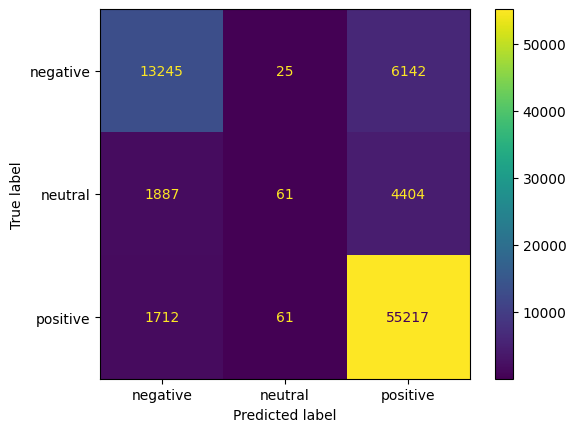

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    test_labels,
    predictions,
    labels=['negative', 'neutral', 'positive']
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['negative', 'neutral', 'positive']
)

disp.plot()
plt.show()